### Tugas Mandiri W11

Rosa ingin berwisata dari kota Malang menuju kota Surabaya dengan rute yang paling 
efisien. Jarak antar kota (dalam km) dan koordinat setiap kota untuk menghitung nilai 
heuristik.

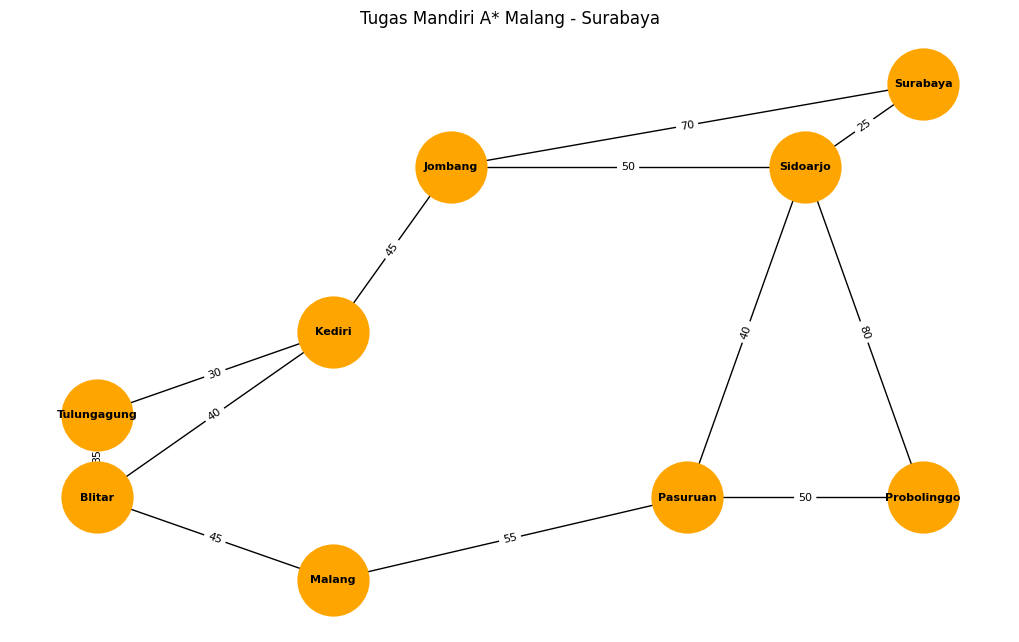

Rute A*:  Malang -> Pasuruan -> Sidoarjo -> Surabaya
Total Jarak: 120 km

[Malang] -> Heuristik ke Surabaya: 117
[Pasuruan] -> Heuristik ke Surabaya: 72
[Sidoarjo] -> Heuristik ke Surabaya: 25
[Surabaya] -> ✅ TELAH TIBA DI TUJUAN (Heuristik: 0)


In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import math
 
#Membuat wadah kosong untuk graph undirected
G_undirected = nx.Graph()

# Inisialisasi Weight tiap node
edge_weight_data = [
    ('Malang', 'Blitar', 45),
    ('Malang', 'Pasuruan', 55),
    ('Blitar', 'Tulungagung', 35),
    ('Blitar', 'Kediri', 40),
    ('Tulungagung', 'Kediri', 30),
    ('Kediri', 'Jombang', 45),
    ('Pasuruan', 'Sidoarjo', 40),
    ('Pasuruan', 'Probolinggo', 50),
    ('Probolinggo', 'Sidoarjo', 80),
    ('Jombang', 'Sidoarjo', 50),
    ('Jombang', 'Surabaya', 70),
    ('Sidoarjo', 'Surabaya', 25),

]
 
#Membuat daftar untuk agar saling terhubung
G_undirected.add_weighted_edges_from(edge_weight_data)
 
#Menentukan posisi sesuai gambar menggunakan koordinat
pos = {
    'Malang': (2, 0), 
    'Blitar': (0, 1), 
    'Tulungagung': (0, 2), 
    'Kediri': (2, 3), 
    'Pasuruan': (5, 1), 
    'Probolinggo': (7, 1), 
    'Jombang': (3, 5), 
    'Sidoarjo': (6, 5), 
    'Surabaya': (7, 6), 

}
 
#Set ukuran framenya
plt.figure(figsize=(10, 6))

#Menggambar node
nx.draw(G_undirected, pos, with_labels=True, node_color='orange', 
        node_shape='o', node_size=2500, font_size=8, font_weight='bold',
        edge_color='black', linewidths=2)
edge_labels = nx.get_edge_attributes(G_undirected, 'weight')
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels, font_size=8)

 
#Data weight
edge_labels = nx.get_edge_attributes(G_undirected, 'weight')
 
#Tulisan bobot pada edges
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels, font_size=8)
 
plt.title("Tugas Mandiri A* Malang - Surabaya")
plt.axis('off')
plt.show()
 
# Nilai heuristik yg telah ditetapkan
h_table = {
    'Malang': 117, 'Blitar': 125, 'Tulungagung': 111,
    'Kediri': 90, 'Pasuruan': 72, 'Probolinggo': 90,
    'Jombang': 56, 'Sidoarjo': 25, 'Surabaya': 0
}
 
# Fungsi Heuristik menggunakan Euclidean Distance
def heuristable(u, v):
    return h_table[u]


path_node = nx.astar_path(
    G_undirected, 
    "Malang", 
    "Surabaya", 
    heuristic=heuristable, 
    weight='weight'
) 

# Mendapatkan total jarak
total_jarak = nx.path_weight(G_undirected, path_node, weight='weight')

# Cetak Hasil
print("Rute A*: " , " -> " .join(path_node))
print(f"Total Jarak: {total_jarak} km\n")

for node in path_node:
    # Menghitung jarak dari node saat ini ke tujuan (Surabaya)
    h_value = heuristable(node, "Surabaya")
    
    if node == "Surabaya":
        print(f"[{node}] -> ✅ TELAH TIBA DI TUJUAN (Heuristik: {h_value})")
    else:
        print(f"[{node}] -> Heuristik ke {"Surabaya"}: {h_value}")
 
